**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载地址（4月17日前有效）：https://f.ws59.cn/f/du8yd2536vl
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。
  - 原数完整据集下载地址：https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing \
    或国内访问地址（4月17日前有效）：https://f.ws59.cn/f/du8xu130kba

## 1. 实验准备

In [1]:
# 1. 导入必要的库
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. 数据预处理

In [2]:
# 2. 数据预处理
def load_json_data(json_file):
    """加载JSON格式的数据集"""
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

# 加载训练集和测试集
train_data = load_json_data('trainset.json')
test_data = load_json_data('testset.json')

- 数据集信息展示

In [3]:
# 打印数据集信息
print(f"训练集样本数: {len(train_data)}")
print(f"测试集样本数: {len(test_data)}")

# 查看数据样例
print("\n训练集样例:")
print(train_data[0])

# 统计说话人和方言区域的分布
train_speakers = set([item['speaker_id'] for item in train_data])
test_speakers = set([item['speaker_id'] for item in test_data])
train_dialects = set([item['dialect_region'] for item in train_data])

print(f"\n训练集包含 {len(train_speakers)} 位说话人")
print(f"测试集包含 {len(test_speakers)} 位说话人")
print(f"数据集包含 {len(train_dialects)} 个方言区域")

# 创建说话人ID到索引的映射
all_speakers = sorted(list(train_speakers.union(test_speakers)))
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(all_speakers)}
idx_to_speaker = {idx: speaker for speaker, idx in speaker_to_idx.items()}

print(f"\n共有 {len(speaker_to_idx)} 位说话人")


训练集样本数: 2772
测试集样本数: 924

训练集样例:
{'audio_filepath': './Dataset/TRAIN/DR1/FCJF0/SI648_.wav', 'dialect_region': 'DR1', 'gender': 'F', 'speaker_id': 'CJF0'}

训练集包含 462 位说话人
测试集包含 462 位说话人
数据集包含 8 个方言区域

共有 462 位说话人


- 数据集信息可视化

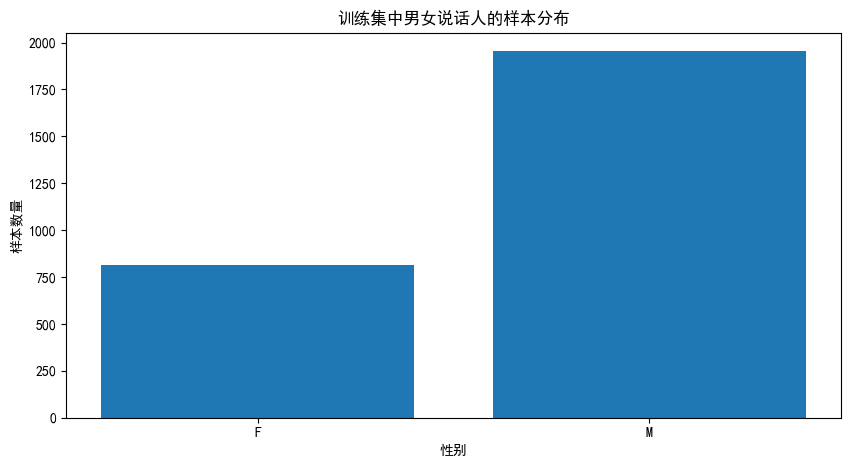


显示样本音频: ./Dataset/TRAIN/DR1/FCJF0/SI648_.wav


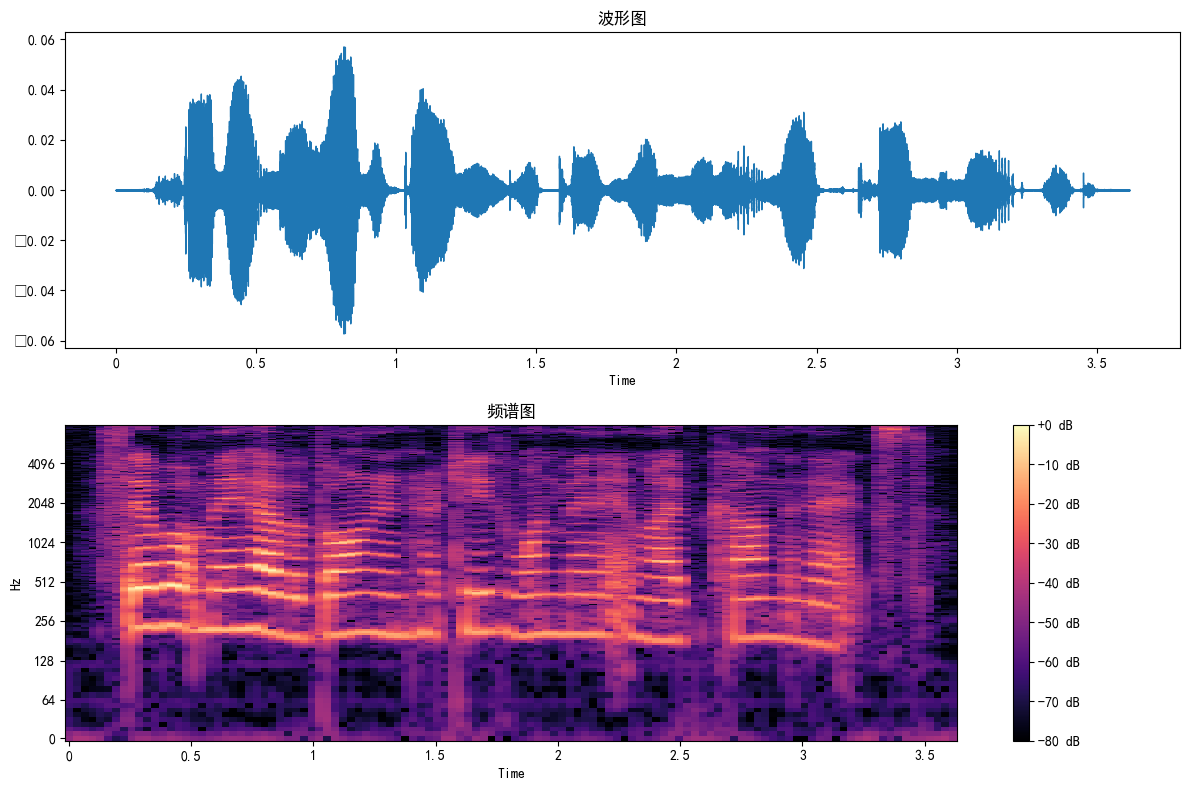

In [5]:
# 可视化数据集中的音频样本分布
train_gender_counts = {"F": 0, "M": 0}
for item in train_data:
    train_gender_counts[item['gender']] += 1

plt.figure(figsize=(10, 5))
plt.bar(train_gender_counts.keys(), train_gender_counts.values())
plt.title('训练集中男女说话人的样本分布')
plt.xlabel('性别')
plt.ylabel('样本数量')
plt.show()

# 可视化一个音频样本的波形
def plot_audio_sample(audio_path):
    """绘制音频波形和频谱图"""
    y, sr = librosa.load(audio_path, sr=None)
    
    plt.rcParams['font.family'] = 'SimHei'
    plt.figure(figsize=(12, 8))
    
    # 波形图
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('波形图')
    
    # 频谱图
    plt.subplot(2, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('频谱图')
    
    plt.tight_layout()
    plt.show()

# 展示一个样本的波形和频谱，以确认加载成功
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    print(f"\n显示样本音频: {sample_path}")
    plot_audio_sample(sample_path)

## 3. 特征提取 —— MFCC梅尔频率倒谱系数
是一种用来表达语音的声音特征的方法。

- 添加了二阶差分 <br>

| 如果只看 MFCC | 加入 一阶差分 和 二阶差分 |
|-----------|--------------|
| 就像拍了一张语音的“快照”，知道它此刻长什么样 | 就像拍了“连续剧”，能看到语音在怎么变化 |
| 不容易区分“啊”和“呀”等发音，因为它们瞬间特征差不多 | 更容易捕捉“啊变成呀”的过程，区别更明显 |
| 缺乏上下文，模型更容易迷糊 | 有时间上下文信息，模型更聪明 |


In [7]:
# 3. 特征提取 - MFCC (Mel-Frequency Cepstral Coefficients)
def extract_mfcc_features(audio_path, n_mfcc=20):
    """
    从音频文件中提取MFCC特征
    
    参数:
    audio_path: 音频文件路径
    n_mfcc: MFCC系数数量
    
    返回:
    mfccs: MFCC特征矩阵 (时间帧数 × MFCC系数数)
    """
    y, sr = librosa.load(audio_path, sr=None)
    
    # 提取MFCC特征
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc) # libsora生成的 mfccs 的 shape 是 (n_mfcc, time_frames)
    
    # 使用deltas和delta-deltas增强特征
    delta_mfccs = librosa.feature.delta(mfccs) # 一阶差分会比较当前帧和前后帧的值 → 得到一个“变化趋势” ( 看“数值涨了还是跌了”)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2) # 二阶差分 相当于"加速度”，能识别更精细的语音变化，比如发音拐点、音调突然变化等。(看“涨得快不快”)
    
    # 通过在特征维度concat合并原始MFCC与其一阶和二阶差分结果
    combined_mfccs = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0) # 这里设置axis=0 因为需要在n_mfcc维度拼接，而非time_frames维度
    
    # 转置为时间帧 × 特征维度的格式
    return combined_mfccs.T

# 可视化MFCC特征
def visualize_mfcc(mfccs, title="MFCC特征"):
    """可视化MFCC特征矩阵"""
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mfccs.T, x_axis='time') # librosa.display.specshow 函数期望输入的维度形状是 (n_mfcc, time_frames) ,所以要转置
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.ylabel("MFCC系数索引")
    plt.xlabel("时间 (秒)")
    plt.tight_layout()
    plt.show()

# 为训练集和测试集提取MFCC特征
def prepare_features_for_gmm(data, n_mfcc=20):
    """
    为GMM模型准备特征集和标签集
    
    返回:
    features_dict: 按说话人ID组织的特征字典
    """
    features_dict = {}
    
    for item in data:
        speaker_id = item['speaker_id']
        
        if speaker_id not in features_dict:
            features_dict[speaker_id] = []
        
        # 提取特征
        mfccs = extract_mfcc_features(item['audio_filepath'], n_mfcc)
        features_dict[speaker_id].append(mfccs)
    
    # 合并每个说话人的所有特征
    for speaker_id in features_dict:
        features_dict[speaker_id] = np.vstack(features_dict[speaker_id])
    
    return features_dict


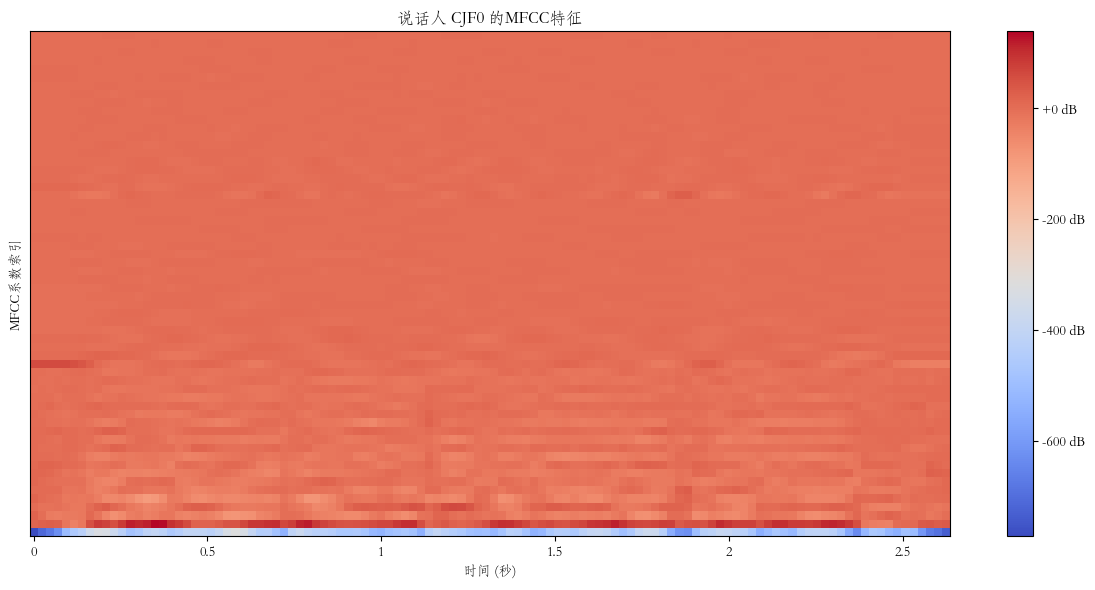

正在为训练集提取MFCC特征...
正在为测试集提取MFCC特征...
特征提取完成!


In [8]:
# 使用训练集样本可视化MFCC特征
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    sample_speaker = train_data[0]['speaker_id']
    
    # 提取并显示MFCC特征
    mfccs = extract_mfcc_features(sample_path) 
    visualize_mfcc(mfccs, f"说话人 {sample_speaker} 的MFCC特征")

print("正在为训练集提取MFCC特征...")
train_features_dict = prepare_features_for_gmm(train_data)

print("正在为测试集提取MFCC特征...")
test_features_dict = prepare_features_for_gmm(test_data)

print("特征提取完成!")

- MFCC特征图图像解读：
- 语音片段 vs 静音片段<br>
有语音的时间段：图上出现明显的颜色波动、斑块，像条纹或带状结构。
<br>
静音的地方：颜色趋于一致、平滑，整段暗蓝，没有明显波动。<br>

- 元音 vs 辅音<br>
元音：比较持续，颜色块宽大，变化慢。
<br>
辅音（尤其是爆破音、摩擦音）：突变明显，看起来像一条一条的窄条纹，瞬间颜色突变。<br>

- 说话内容越丰富，图案越复杂<br>
如果有人在短时间说了很多话，会看到图上花纹密集、频繁变化。
<br>
如果是读数字或短句，变化会更规律。<br>

## 4. 模型选择和训练 - GMM (Gaussian Mixture Model)

In [7]:
# 4. 模型选择和训练 - GMM (Gaussian Mixture Model)
from sklearn.mixture import GaussianMixture

def train_gmm_per_speaker(features_dict, n_components=8):
    """
    为每位说话人训练独立的GMM模型
    
    参数:
    features_dict: 按说话人ID组织的特征字典
    n_components: 高斯混合成分数量
    
    返回:
    gmms: 以说话人ID为键，GMM模型为值的字典
    """
    gmms = {}
    
    for speaker_id, features in features_dict.items():
        print(f"训练说话人 {speaker_id} 的GMM模型...")
        
        # 创建并训练GMM模型
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type='diag',  # 使用对角协方差矩阵
            max_iter=200,
            random_state=42
        )
        
        gmm.fit(features)
        gmms[speaker_id] = gmm
    
    return gmms


In [8]:
# 训练GMM模型
print("开始GMM模型训练...")
n_components = 8  # 高斯混合成分数量
gmm_models = train_gmm_per_speaker(train_features_dict, n_components)
print("GMM模型训练完成!")

开始GMM模型训练...
训练说话人 CJF0 的GMM模型...
训练说话人 DAW0 的GMM模型...
训练说话人 DML0 的GMM模型...
训练说话人 ECD0 的GMM模型...
训练说话人 ETB0 的GMM模型...
训练说话人 JSP0 的GMM模型...
训练说话人 KFB0 的GMM模型...
训练说话人 MEM0 的GMM模型...
训练说话人 SAH0 的GMM模型...
训练说话人 SJK1 的GMM模型...
训练说话人 SMA0 的GMM模型...
训练说话人 TBR0 的GMM模型...
训练说话人 VFB0 的GMM模型...
训练说话人 VMH0 的GMM模型...
训练说话人 CPM0 的GMM模型...
训练说话人 DAC0 的GMM模型...
训练说话人 DPK0 的GMM模型...
训练说话人 EDR0 的GMM模型...
训练说话人 GRL0 的GMM模型...
训练说话人 JEB1 的GMM模型...
训练说话人 JWT0 的GMM模型...
训练说话人 KLS0 的GMM模型...
训练说话人 KLW0 的GMM模型...
训练说话人 MGG0 的GMM模型...
训练说话人 MRP0 的GMM模型...
训练说话人 PGH0 的GMM模型...
训练说话人 PGR0 的GMM模型...
训练说话人 PSW0 的GMM模型...
训练说话人 RAI0 的GMM模型...
训练说话人 RCG0 的GMM模型...
训练说话人 RDD0 的GMM模型...
训练说话人 RSO0 的GMM模型...
训练说话人 RWS0 的GMM模型...
训练说话人 TJS0 的GMM模型...
训练说话人 TPF0 的GMM模型...
训练说话人 TRR0 的GMM模型...
训练说话人 WAD0 的GMM模型...
训练说话人 WAR0 的GMM模型...
训练说话人 AEM0 的GMM模型...
训练说话人 AJW0 的GMM模型...
训练说话人 CAJ0 的GMM模型...
训练说话人 CMM0 的GMM模型...
训练说话人 CYL0 的GMM模型...
训练说话人 DAS1 的GMM模型...
训练说话人 DNC0 的GMM模型...
训练说话人 DXW0 的GMM模型...
训练说话人 EAC0 的GMM模型...


## 5. 评价指标(准确率Accuracy)

In [9]:
# 5. 评估和分析
def evaluate_gmm_models(gmm_models, test_features_dict):
    """
    评估GMM模型在测试集上的性能
    
    返回:
    true_speakers: 真实说话人ID列表
    pred_speakers: 预测说话人ID列表
    accuracy: 准确率
    """
    true_speakers = []
    pred_speakers = []
    
    for true_speaker, features in test_features_dict.items():
        # 对每个测试样本的每一帧计算对数似然
        scores = {}
        for speaker_id, gmm in gmm_models.items():
            scores[speaker_id] = gmm.score_samples(features).mean()
        
        # 找出似然得分最高的说话人
        predicted_speaker = max(scores, key=scores.get)
        
        # 记录真实标签和预测标签
        true_speakers.append(true_speaker)
        pred_speakers.append(predicted_speaker)
    
    # 计算准确率
    correct = sum(1 for t, p in zip(true_speakers, pred_speakers) if t == p)
    accuracy = correct / len(true_speakers)
    
    return true_speakers, pred_speakers, accuracy

# 评估模型性能
print("评估GMM模型性能...")
true_speakers, pred_speakers, accuracy = evaluate_gmm_models(gmm_models, test_features_dict)
print(f"GMM模型准确率: {accuracy:.4f}")

评估GMM模型性能...
GMM模型准确率: 0.9286


##  6. 分析和可视化


GMM模型分类报告:
              precision    recall  f1-score   support

        ABC0       1.00      1.00      1.00         1
        ADC0       1.00      1.00      1.00         1
        ADD0       0.50      1.00      0.67         1
        AEB0       1.00      1.00      1.00         1
        AEM0       0.00      0.00      0.00         1
        AEO0       0.50      1.00      0.67         1
        AFM0       1.00      1.00      1.00         1
        AJP0       1.00      1.00      1.00         1
        AJW0       1.00      1.00      1.00         1
        AKB0       1.00      1.00      1.00         1
        AKR0       1.00      1.00      1.00         1
        ALK0       1.00      1.00      1.00         1
        ALR0       0.00      0.00      0.00         1
        APB0       1.00      1.00      1.00         1
        APV0       1.00      1.00      1.00         1
        ARC0       1.00      1.00      1.00         1
        ARW0       1.00      1.00      1.00         1
        BAR0   

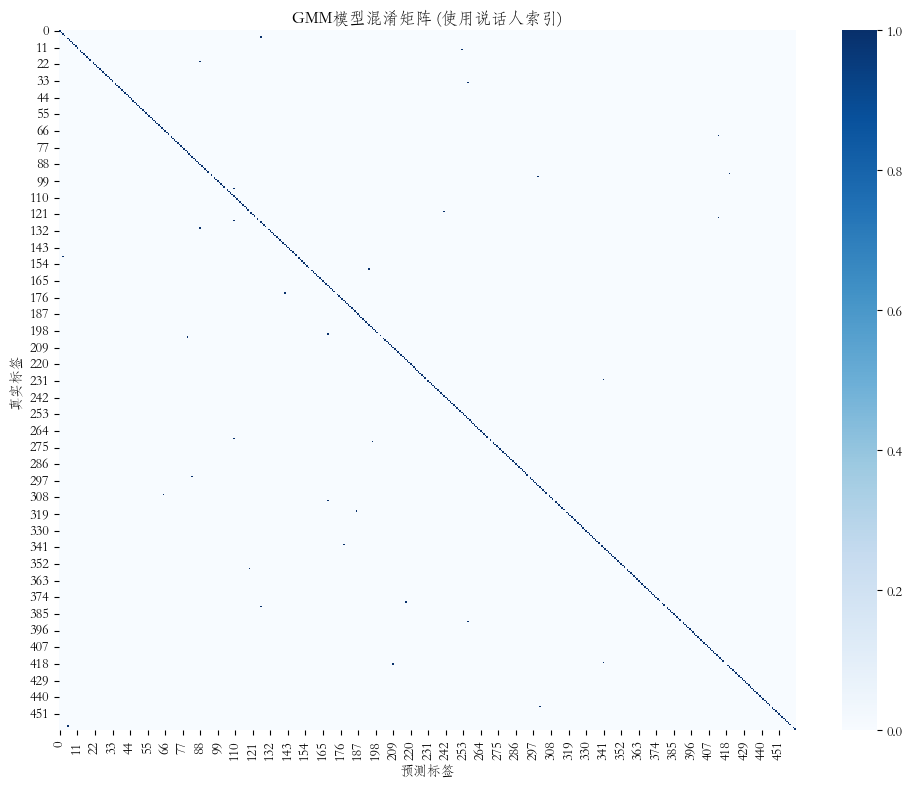

In [50]:
# 可视化混淆矩阵
def plot_confusion_matrix(true_labels, pred_labels):
    """绘制混淆矩阵"""
    # 为每个说话人分配数字ID
    unique_speakers = sorted(set(true_labels).union(set(pred_labels)))
    speaker_to_id = {speaker: i for i, speaker in enumerate(unique_speakers)}
    
    # 转换为数字ID
    true_ids = [speaker_to_id[speaker] for speaker in true_labels]
    pred_ids = [speaker_to_id[speaker] for speaker in pred_labels]
    
    # 计算混淆矩阵
    n_speakers = len(unique_speakers)
    cm = np.zeros((n_speakers, n_speakers))
    
    for t, p in zip(true_ids, pred_ids):
        cm[t, p] += 1
    
    # 创建带有标签的DataFrame
    if n_speakers <= 15:  # 如果说话人数量较少，使用原始标签
        df_cm = pd.DataFrame(cm, index=unique_speakers, columns=unique_speakers)
        title = 'GMM模型混淆矩阵'
    else:  # 对于大量说话人，使用数字索引
        df_cm = pd.DataFrame(cm)
        title = 'GMM模型混淆矩阵 (使用说话人索引)'
    
    # 绘制混淆矩阵
    plt.figure(figsize=(10, 8))
    
    # 如果说话人数量很多，使用更紧凑的热图而不是带注释的版本
    if n_speakers > 40:
        sns.heatmap(df_cm, cmap='Blues')
    else:
        # 对于中等数量的说话人，使用带数值的热图
        sns.heatmap(df_cm, annot=(n_speakers <= 15), fmt='g' if n_speakers <= 15 else '.2f', 
                   cmap='Blues')
    
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 输出分类报告
print("\nGMM模型分类报告:")
print(classification_report(true_speakers, pred_speakers))

# 绘制混淆矩阵
plot_confusion_matrix(true_speakers, pred_speakers)

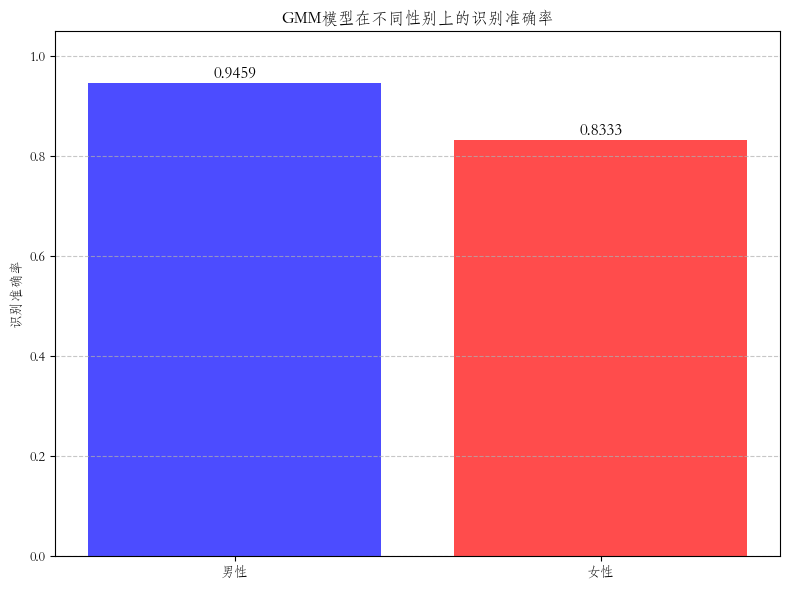

<Figure size 1000x800 with 0 Axes>

In [28]:
# 分析性别因素对识别准确率的影响
def analyze_gender_impact(true_speakers, pred_speakers):
    """分析说话人性别对GMM模型性能的影响"""
    # 从说话人ID中提取性别信息（假设第一个字符是'F'表示女性，'M'表示男性）
    gender_dict = {}
    for speaker in set(true_speakers):
        gender_dict[speaker] = speaker[0] if speaker[0] in ['F', 'M'] else 'U'
    
    # 按性别分组计算准确率
    male_indices = [i for i, spk in enumerate(true_speakers) if gender_dict.get(spk) == 'M']
    female_indices = [i for i, spk in enumerate(true_speakers) if gender_dict.get(spk) == 'F']
    
    # 计算每个性别的准确率
    male_accuracy = 0
    if male_indices:
        male_true = [true_speakers[i] for i in male_indices]
        male_pred = [pred_speakers[i] for i in male_indices]
        male_accuracy = np.mean(np.array(male_true) == np.array(male_pred))
    
    female_accuracy = 0
    if female_indices:
        female_true = [true_speakers[i] for i in female_indices]
        female_pred = [pred_speakers[i] for i in female_indices]
        female_accuracy = np.mean(np.array(female_true) == np.array(female_pred))
    
    # 绘制性别对比图
    plt.figure(figsize=(8, 6))
    plt.bar(['男性', '女性'], [male_accuracy, female_accuracy], color=['blue', 'red'], alpha=0.7)
    
    # 添加准确率标签
    plt.text(0, male_accuracy + 0.01, f'{male_accuracy:.4f}', ha='center', fontsize=12)
    plt.text(1, female_accuracy + 0.01, f'{female_accuracy:.4f}', ha='center', fontsize=12)
    
    plt.ylim(0, 1.05)
    plt.ylabel('识别准确率')
    plt.title('GMM模型在不同性别上的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 分析性别间的混淆情况
    errors = [(true, pred) for true, pred in zip(true_speakers, pred_speakers) if true != pred]
    
    gender_confusion = {
        'MM': 0,  # 男性识别为男性(但不同人)
        'MF': 0,  # 男性错误识别为女性
        'FM': 0,  # 女性错误识别为男性
        'FF': 0   # 女性识别为女性(但不同人)
    }
    
    for true, pred in errors:
        true_gender = gender_dict.get(true, 'U')
        pred_gender = gender_dict.get(pred, 'U')
        
        if true_gender in 'MF' and pred_gender in 'MF':
            gender_confusion[true_gender + pred_gender] += 1
    
    # 绘制性别混淆饼图
    plt.figure(figsize=(10, 8))
    labels = ['男性→其他男性', '男性→女性', '女性→男性', '女性→其他女性']
    sizes = [gender_confusion['MM'], gender_confusion['MF'], 
             gender_confusion['FM'], gender_confusion['FF']]
    
    # 检查是否有数据
    if sum(sizes) > 0:
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
                colors=['lightblue', 'lightgreen', 'salmon', 'khaki'])
        plt.axis('equal')
        plt.title('GMM模型性别相关的错误分布')
        plt.tight_layout()
        plt.show()

# 分析性别因素影响
analyze_gender_impact(true_speakers, pred_speakers)

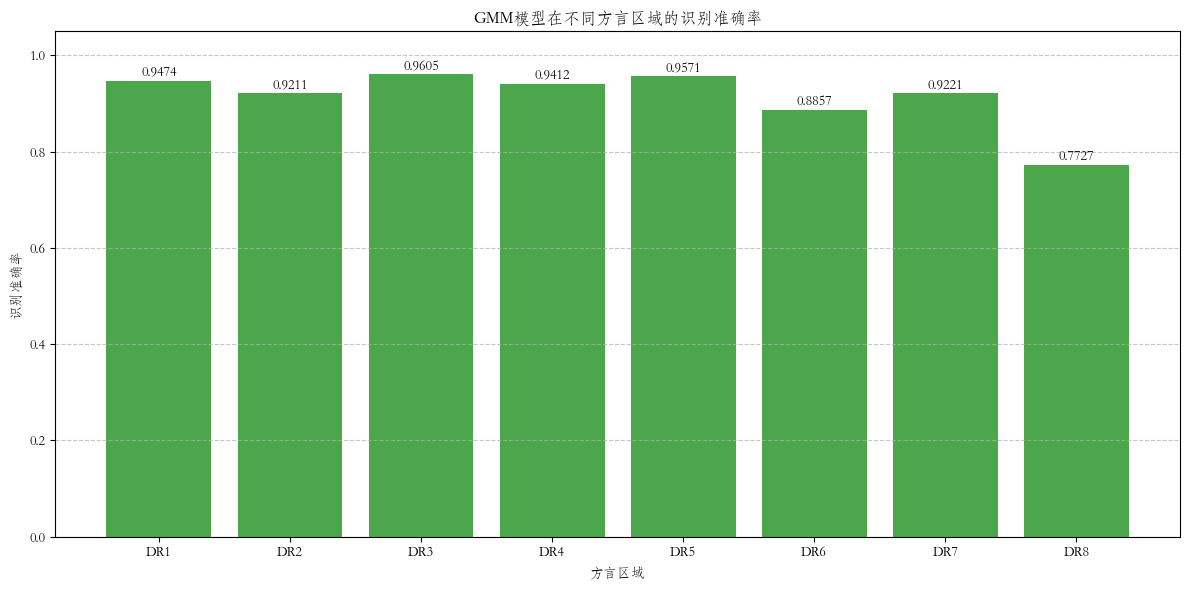

In [29]:
# 分析方言区域对识别准确率的影响
def analyze_dialect_impact(true_speakers, pred_speakers):
    """分析方言区域对GMM模型性能的影响"""
    # 从说话人文件路径中提取方言区域信息
    dialect_dict = {}
    for speaker in set(true_speakers):
        # 在实际代码中，你需要根据数据结构获取方言信息
        # 这里假设我们已经有这个信息
        for item in test_data:
            if item['speaker_id'] == speaker:
                dialect_dict[speaker] = item['dialect_region']
                break
    
    # 按方言区域分组计算准确率
    dialect_regions = sorted(set(dialect_dict.values()))
    dialect_accuracies = {}
    
    for dialect in dialect_regions:
        dialect_indices = [i for i, spk in enumerate(true_speakers) if dialect_dict.get(spk) == dialect]
        
        if not dialect_indices:
            continue
            
        true_dialect = [true_speakers[i] for i in dialect_indices]
        pred_dialect = [pred_speakers[i] for i in dialect_indices]
        
        accuracy = np.mean(np.array(true_dialect) == np.array(pred_dialect))
        dialect_accuracies[dialect] = accuracy
    
    # 绘制方言区域准确率条形图
    plt.figure(figsize=(12, 6))
    regions = list(dialect_accuracies.keys())
    accuracies = list(dialect_accuracies.values())
    
    plt.bar(regions, accuracies, color='green', alpha=0.7)
    
    # 添加准确率标签
    for i, v in enumerate(accuracies):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    
    plt.ylim(0, 1.05)
    plt.xlabel('方言区域')
    plt.ylabel('识别准确率')
    plt.title('GMM模型在不同方言区域的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 分析方言区域影响
analyze_dialect_impact(true_speakers, pred_speakers)

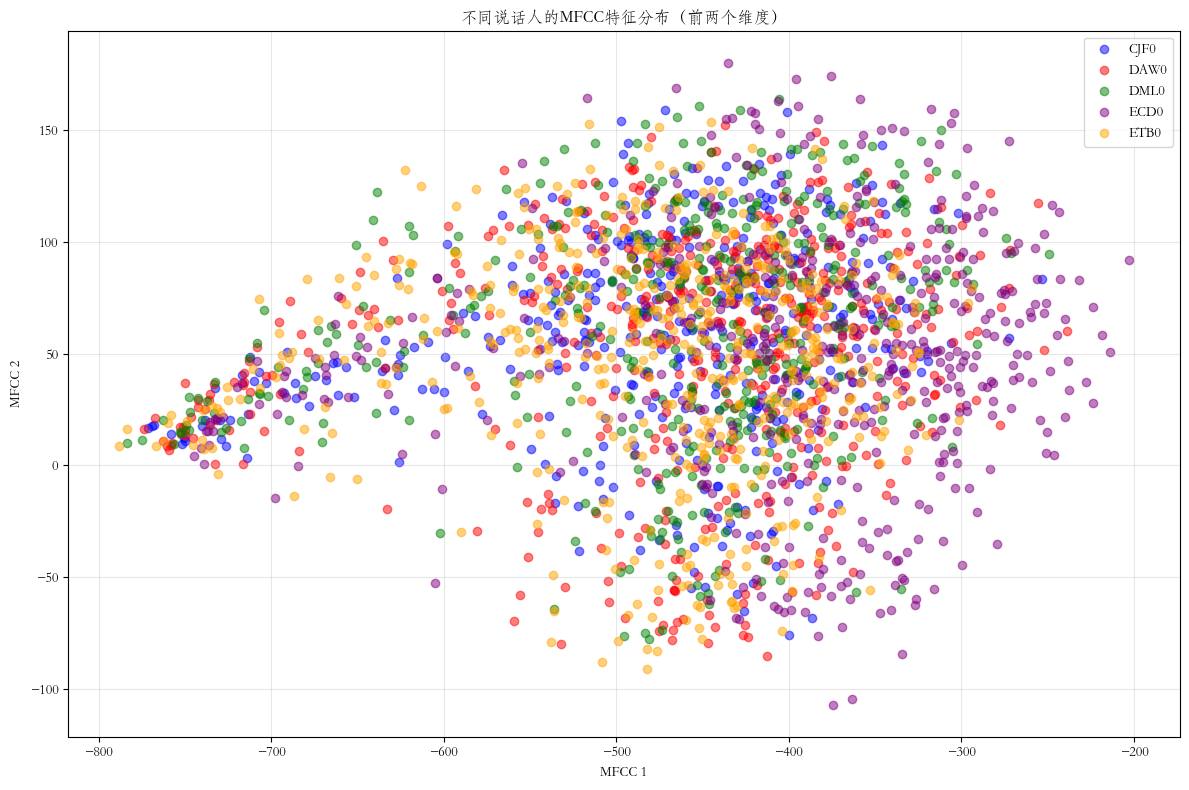

In [38]:
# 可视化MFCC特征的分布
def visualize_mfcc_distribution(features_dict):
    """可视化不同说话人的MFCC特征分布"""
    plt.figure(figsize=(12, 8))
    
    # 为了可视化目的，选择前5个说话人和前2个MFCC维度
    speakers = list(features_dict.keys())[:5]
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i, speaker in enumerate(speakers):
        # 选择每个说话人的部分样本以避免图像过于拥挤
        features = features_dict[speaker]
        if len(features) > 500:
            indices = np.random.choice(len(features), 500, replace=False)
            samples = features[indices]
        else:
            samples = features
        
        # 绘制前两个MFCC维度的散点图
        plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, color=colors[i], label=speaker)
    
    plt.xlabel('MFCC 1')
    plt.ylabel('MFCC 2')
    plt.title('不同说话人的MFCC特征分布（前两个维度）')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 可视化MFCC特征分布
visualize_mfcc_distribution(train_features_dict)

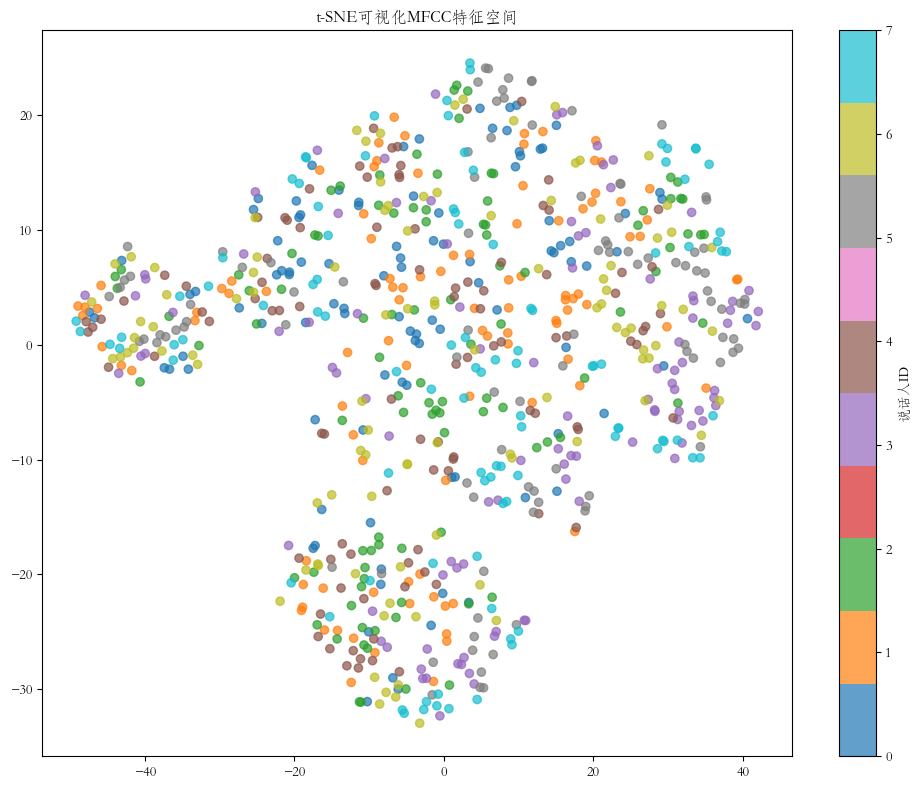

In [49]:
# 使用t-SNE降维可视化高维MFCC特征
def visualize_tsne(features_dict, speaker_ids):
    """使用t-SNE降维可视化MFCC特征"""
    from sklearn.manifold import TSNE
    
    # 准备数据
    features = []
    labels = []
    
    # 限制每个说话人的样本数，避免数据不平衡
    samples_per_speaker = 100
    
    for speaker in speaker_ids:
        if speaker not in features_dict:
            continue
            
        speaker_features = features_dict[speaker]
        
        # 样本太多，随机选择一部分
        if len(speaker_features) > samples_per_speaker:
            indices = np.random.choice(len(speaker_features), samples_per_speaker, replace=False)
            selected_features = speaker_features[indices]
        else:
            selected_features = speaker_features
        
        features.append(selected_features)
        labels.extend([speaker] * len(selected_features))
    
    # 合并所有特征
    all_features = np.vstack(features)
    
    # 使用t-SNE降维
    tsne = TSNE(n_components=2, random_state=42)
    embedded_features = tsne.fit_transform(all_features)
    
    # 创建唯一标签到索引的映射
    unique_labels = sorted(set(labels))
    label_to_idx = {label: i for i, label in enumerate(unique_labels)}
    
    # 将标签转换为索引
    label_indices = [label_to_idx[label] for label in labels]
    
    # 绘制t-SNE结果
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embedded_features[:, 0], embedded_features[:, 1], 
                         c=label_indices, cmap='tab10', alpha=0.7)
    
    plt.title('t-SNE可视化MFCC特征空间')
    plt.colorbar(scatter, label='说话人ID')
    plt.tight_layout()
    plt.show()

# 使用t-SNE可视化（选择前8个说话人）
top_speakers = list(train_features_dict.keys())[:8]
visualize_tsne(train_features_dict, top_speakers)

## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。